> Notebook en progreso! 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split
from torchvision.transforms import v2 as T
from torchvision.io import read_image, ImageReadMode

from torchinfo import summary

import os
from pathlib import Path

from utils import train, plot_training, model_classification_report, show_tensor_image

In [ ]:
from utils import get_device, get_num_workers

DEVICE = get_device()  # cuda > mps > xpu > cpu
NUM_WORKERS = get_num_workers()  # Linux: mitad de los núcleos disponibles, entre 1 y 8; Windows/macOS: 0 (ver docstring)

print(f"Usando {DEVICE}")
print(f"Usando {NUM_WORKERS}")

BATCH_SIZE = 16  # tamaño del batch

Usando cuda
Usando 4


In [ ]:
TRAIN_DIR = Path("data/imagenette2-320/train")
TEST_DIR = Path("data/imagenette2-320/val")
DIM = 224  # dimensión de las imágenes

train_transforms = T.Compose(
    [
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.RandomResizedCrop((DIM, DIM)),
        T.RandomHorizontalFlip(),
    ]
)

test_transforms = T.Compose(
    [
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Resize(256, antialias=True),
        T.CenterCrop((DIM, DIM)),
    ]
)

imagenet_train_dataset = datasets.Imagenette(
    TRAIN_DIR, download=False, size="320px", split="train", transform=train_transforms
)

imagenet_test_dataset = datasets.Imagenette(
    TEST_DIR, download=False, size="320px", split="val", transform=test_transforms
)

In [166]:
show_tensor_image(train_transforms[1][0], vmin=0, vmax=1)

TypeError: 'Compose' object is not subscriptable

In [ ]:
def get_dataloaders(
    train_dataset,
    val_dataset,
    test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    )

    return train_loader, test_loader


train_loader, test_loader = get_dataloaders(
    imagenet_train_dataset, imagenet_test_dataset
)

In [8]:
LEARNING_RATE = 0.001
EPOCHS = 50
CRITERION = nn.CrossEntropyLoss().to(DEVICE)

In [ ]:
def make_layers(cfg, in_channels=3):
    layers = []
    for v in cfg:
        if v == "M":
            layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
        else:
            conv2d = nn.Conv2d(in_channels, v, kernel_size=3, padding=1)
            layers += [conv2d, nn.ReLU(inplace=True)]
            in_channels = v
    return nn.Sequential(*layers)


class VGG(nn.Module):
    def __init__(self, cfg, in_channels=3, num_classes=10, dropout=0.3):
        super().__init__()
        self.features = make_layers(cfg, in_channels=in_channels)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.last_conv_channels = (
            cfg[-2] if cfg[-1] == "M" else cfg[-1]
        )  # asumimos que no termina con dos 'M's
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.last_conv_channels, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = self.classifier(x)
        return x

Modelo VGG-1 con configuración: [32, 'M', 64, 'M']
Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [16, 10]                  --
├─Sequential: 1-1                        [16, 64, 56, 56]          --
│    └─Conv2d: 2-1                       [16, 32, 224, 224]        896
│    └─ReLU: 2-2                         [16, 32, 224, 224]        --
│    └─MaxPool2d: 2-3                    [16, 32, 112, 112]        --
│    └─Conv2d: 2-4                       [16, 64, 112, 112]        18,496
│    └─ReLU: 2-5                         [16, 64, 112, 112]        --
│    └─MaxPool2d: 2-6                    [16, 64, 56, 56]          --
├─AdaptiveAvgPool2d: 1-2                 [16, 64, 1, 1]            --
├─Sequential: 1-3                        [16, 10]                  --
│    └─Flatten: 2-7                      [16, 64]                  --
│    └─Linear: 2-8                       [16, 512]                 33,280
│    └─ReLU: 2-9         

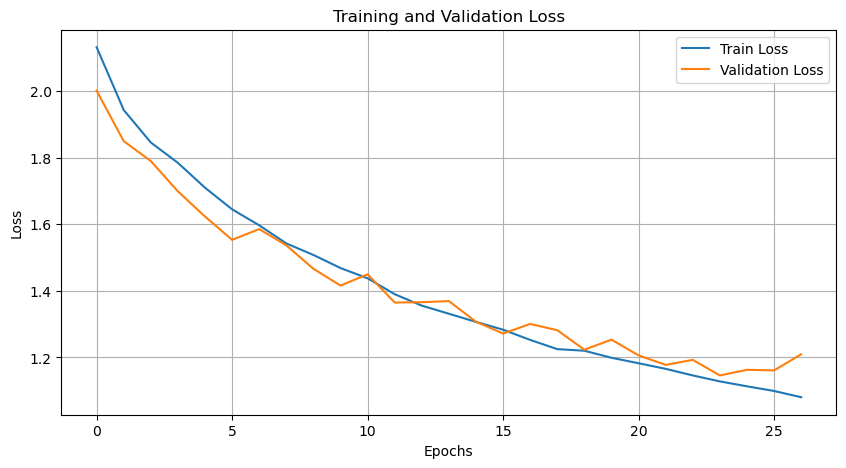

Accuracy: 0.6250

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.56      0.82      0.67       387
           1       0.62      0.61      0.62       395
           2       0.56      0.79      0.66       357
           3       0.64      0.35      0.45       386
           4       0.83      0.49      0.61       409
           5       0.52      0.85      0.64       394
           6       0.61      0.74      0.67       389
           7       0.68      0.43      0.53       419
           8       0.73      0.49      0.59       399
           9       0.75      0.73      0.74       390

    accuracy                           0.62      3925
   macro avg       0.65      0.63      0.62      3925
weighted avg       0.65      0.62      0.62      3925



Modelo VGG-2 con configuración: [32, 32, 'M', 64, 64, 'M']
Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [16, 10]           

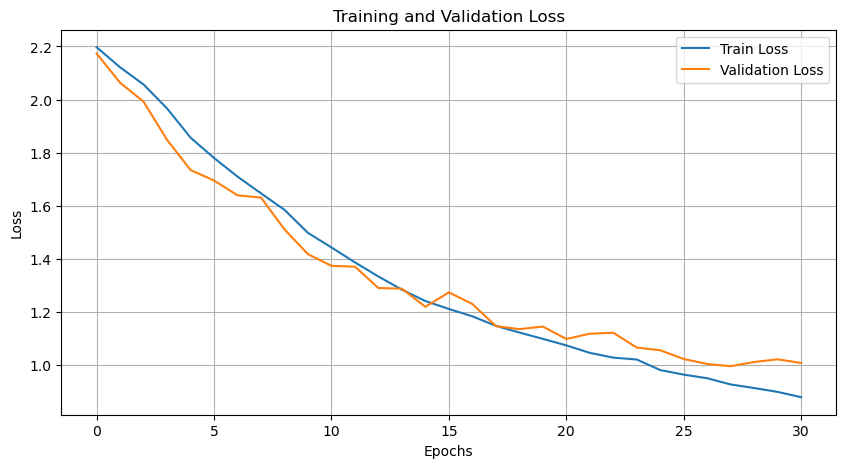

Accuracy: 0.6752

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.62      0.83      0.71       387
           1       0.68      0.69      0.68       395
           2       0.75      0.67      0.71       357
           3       0.59      0.44      0.50       386
           4       0.65      0.77      0.71       409
           5       0.84      0.66      0.74       394
           6       0.80      0.56      0.65       389
           7       0.52      0.70      0.60       419
           8       0.66      0.66      0.66       399
           9       0.81      0.78      0.79       390

    accuracy                           0.68      3925
   macro avg       0.69      0.67      0.67      3925
weighted avg       0.69      0.68      0.67      3925



Modelo VGG-3 con configuración: [32, 32, 'M', 64, 64, 'M', 128, 'M', 256, 'M']
Layer (type:depth-idx)                   Output Shape              Param #
VGG                                     

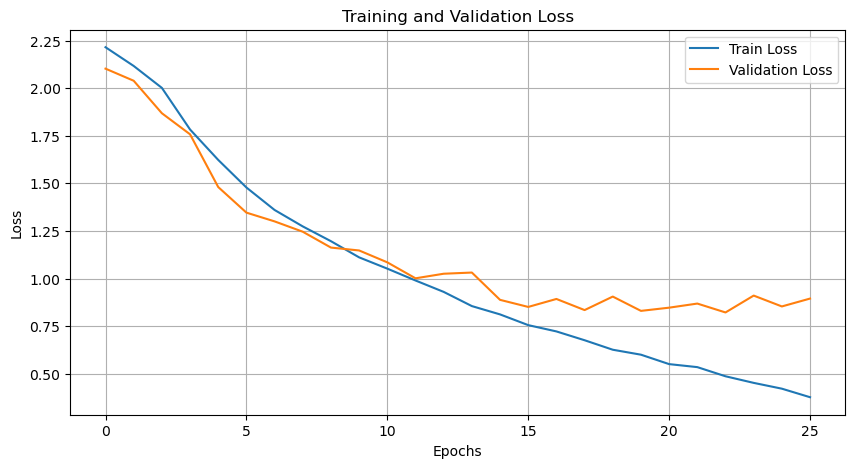

Accuracy: 0.7654

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.81      0.77      0.79       387
           1       0.83      0.85      0.84       395
           2       0.72      0.81      0.76       357
           3       0.66      0.51      0.57       386
           4       0.84      0.83      0.83       409
           5       0.77      0.79      0.78       394
           6       0.72      0.86      0.78       389
           7       0.71      0.71      0.71       419
           8       0.83      0.70      0.76       399
           9       0.77      0.82      0.79       390

    accuracy                           0.77      3925
   macro avg       0.76      0.77      0.76      3925
weighted avg       0.77      0.77      0.76      3925



Modelo VGG-4 con configuración: [32, 32, 'M', 64, 64, 'M', 128, 128, 'M', 256, 256, 'M']
Layer (type:depth-idx)                   Output Shape              Param #
VGG                           

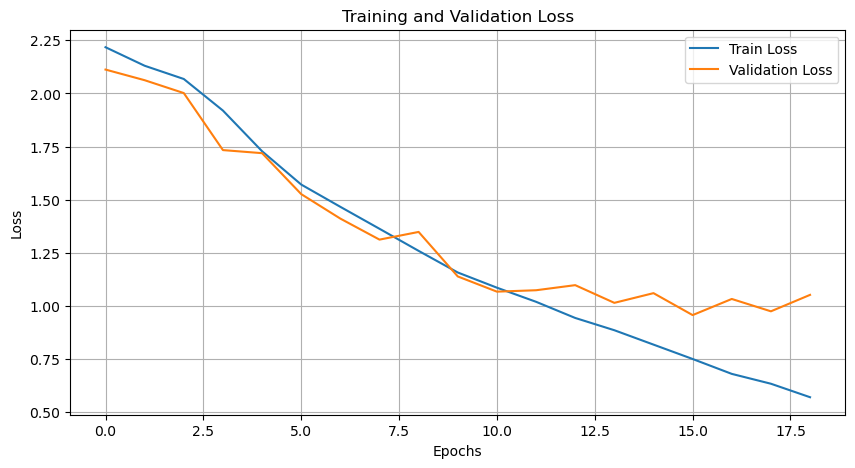

Accuracy: 0.6741

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.73      0.68      0.70       387
           1       0.90      0.66      0.76       395
           2       0.72      0.69      0.71       357
           3       0.58      0.30      0.39       386
           4       0.77      0.70      0.73       409
           5       0.75      0.60      0.67       394
           6       0.47      0.89      0.61       389
           7       0.67      0.67      0.67       419
           8       0.74      0.70      0.72       399
           9       0.65      0.85      0.73       390

    accuracy                           0.67      3925
   macro avg       0.70      0.67      0.67      3925
weighted avg       0.70      0.67      0.67      3925



Modelo VGG-5 con configuración: [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']
Layer (type:depth-idx)                   Output Shape              Param #
VGG          

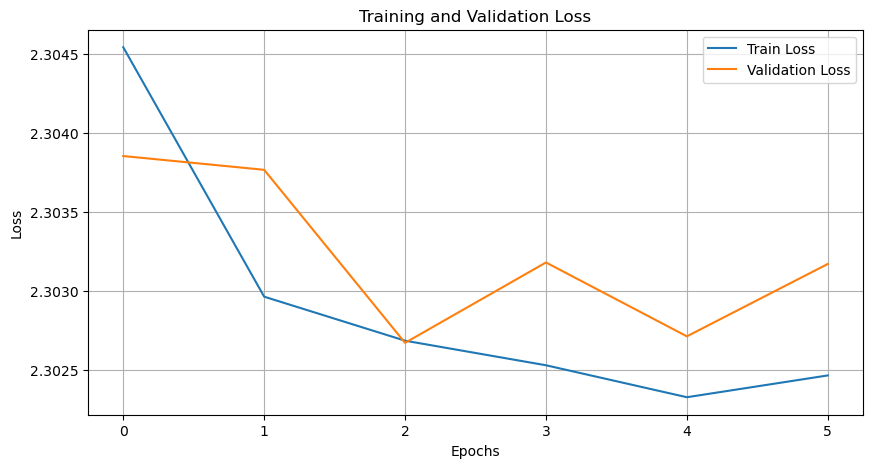

Accuracy: 0.0910

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       387
           1       0.00      0.00      0.00       395
           2       0.09      1.00      0.17       357
           3       0.00      0.00      0.00       386
           4       0.00      0.00      0.00       409
           5       0.00      0.00      0.00       394
           6       0.00      0.00      0.00       389
           7       0.00      0.00      0.00       419
           8       0.00      0.00      0.00       399
           9       0.00      0.00      0.00       390

    accuracy                           0.09      3925
   macro avg       0.01      0.10      0.02      3925
weighted avg       0.01      0.09      0.02      3925



Modelo VGG-6 con configuración: [64, 64, 64, 64, 'M', 128, 128, 128, 128, 'M', 256, 256, 256, 256, 'M', 512, 512, 512, 512, 'M', 512, 512, 512, 512, 'M']
Layer (type:depth-idx)                  

/home/k/.conda/envs/taller-dl-cuda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/k/.conda/envs/taller-dl-cuda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/k/.conda/envs/taller-dl-cuda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

Epoch: 001 | Train Loss: 2.30354 | Val Loss: 2.30392
Epoch: 002 | Train Loss: 2.30296 | Val Loss: 2.30290
Epoch: 003 | Train Loss: 2.30249 | Val Loss: 2.30359
Epoch: 004 | Train Loss: 2.30246 | Val Loss: 2.30342
Epoch: 005 | Train Loss: 2.30234 | Val Loss: 2.30319
Detener entrenamiento en la época 4, la mejor pérdida fue 2.30290


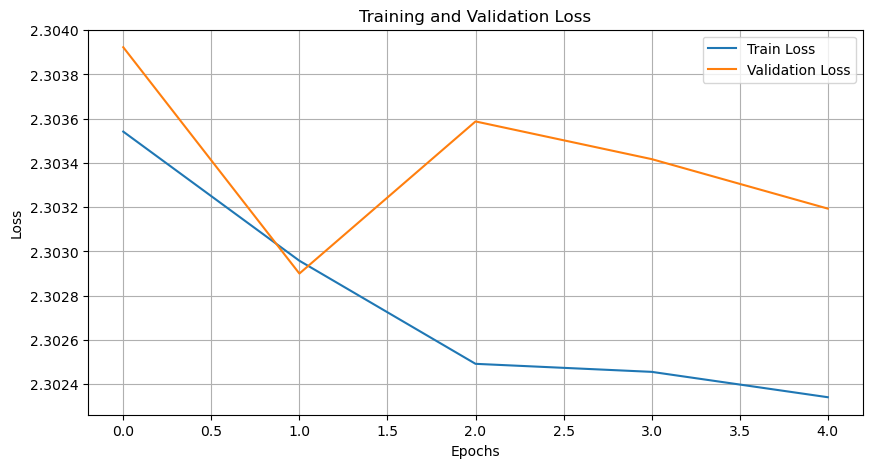

Accuracy: 0.0910

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       387
           1       0.00      0.00      0.00       395
           2       0.09      1.00      0.17       357
           3       0.00      0.00      0.00       386
           4       0.00      0.00      0.00       409
           5       0.00      0.00      0.00       394
           6       0.00      0.00      0.00       389
           7       0.00      0.00      0.00       419
           8       0.00      0.00      0.00       399
           9       0.00      0.00      0.00       390

    accuracy                           0.09      3925
   macro avg       0.01      0.10      0.02      3925
weighted avg       0.01      0.09      0.02      3925





/home/k/.conda/envs/taller-dl-cuda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/k/.conda/envs/taller-dl-cuda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/k/.conda/envs/taller-dl-cuda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [ ]:
cfg_vgg_1 = [32, "M", 64, "M"]

cfg_vgg_2 = [32, 32, "M", 64, 64, "M"]

cfg_vgg_3 = [32, 32, "M", 64, 64, "M", 128, "M", 256, "M"]

cfg_vgg_4 = [32, 32, "M", 64, 64, "M", 128, 128, "M", 256, 256, "M"]

cfg_vgg_5 = [64, 64, "M", 128, 128, "M", 256, 256, "M", 512, 512, "M", 512, 512, "M"]

cfgs = [cfg_vgg_1, cfg_vgg_2, cfg_vgg_3, cfg_vgg_4, cfg_vgg_5]

for i, cfg in enumerate(cfgs):
    print(f"Modelo VGG-{i+1} con configuración: {cfg}")
    model = VGG(cfg, 3, 10).to(DEVICE)
    print(summary(model, input_size=(BATCH_SIZE, 3, DIM, DIM)))
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    train_losses, val_losses = train(
        model=model,
        optimizer=optimizer,
        criterion=CRITERION,
        train_loader=train_loader,
        val_loader=test_loader,
        device=DEVICE,
        do_early_stopping=True,
        patience=3,
        epochs=EPOCHS,
    )
    plot_training(train_losses, val_losses)
    model_classification_report(model, test_loader, device=DEVICE, nclasses=10)
    print("\n" + "=" * 50 + "\n")

In [ ]:
def make_layers_bn(cfg, in_channels=3):
    layers = []
    for v in cfg:
        if v == "M":
            layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
        else:
            conv2d = nn.Conv2d(in_channels, v, kernel_size=3, padding=1)
            layers += [conv2d, nn.BatchNorm2d(v), nn.ReLU(inplace=True)]
            in_channels = v
    return nn.Sequential(*layers)


class VGG_BN(nn.Module):
    def __init__(self, cfg, in_channels=3, num_classes=10, dropout=0.3):
        super().__init__()
        self.features = make_layers_bn(cfg, in_channels=in_channels)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.last_conv_channels = (
            cfg[-2] if cfg[-1] == "M" else cfg[-1]
        )  # asumimos que no termina con dos 'M's
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.last_conv_channels, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = self.classifier(x)
        return x

Modelo VGG_bn-1 con configuración: [32, 'M', 64, 'M']
Layer (type:depth-idx)                   Output Shape              Param #
VGG_BN                                   [16, 10]                  --
├─Sequential: 1-1                        [16, 64, 56, 56]          --
│    └─Conv2d: 2-1                       [16, 32, 224, 224]        896
│    └─BatchNorm2d: 2-2                  [16, 32, 224, 224]        64
│    └─ReLU: 2-3                         [16, 32, 224, 224]        --
│    └─MaxPool2d: 2-4                    [16, 32, 112, 112]        --
│    └─Conv2d: 2-5                       [16, 64, 112, 112]        18,496
│    └─BatchNorm2d: 2-6                  [16, 64, 112, 112]        128
│    └─ReLU: 2-7                         [16, 64, 112, 112]        --
│    └─MaxPool2d: 2-8                    [16, 64, 56, 56]          --
├─AdaptiveAvgPool2d: 1-2                 [16, 64, 1, 1]            --
├─Sequential: 1-3                        [16, 10]                  --
│    └─Flatten: 2-9      

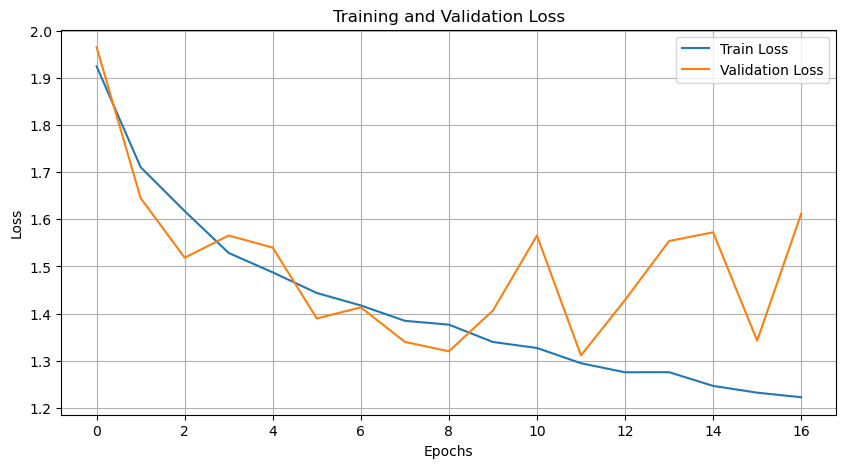

Accuracy: 0.4550

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.73      0.21      0.33       387
           1       0.39      0.64      0.49       395
           2       0.70      0.52      0.60       357
           3       0.55      0.21      0.31       386
           4       0.38      0.81      0.52       409
           5       0.83      0.30      0.44       394
           6       0.36      0.15      0.21       389
           7       0.28      0.78      0.41       419
           8       0.71      0.31      0.44       399
           9       0.90      0.58      0.70       390

    accuracy                           0.46      3925
   macro avg       0.58      0.45      0.44      3925
weighted avg       0.58      0.46      0.44      3925



Modelo VGG_bn-2 con configuración: [32, 32, 'M', 64, 64, 'M']
Layer (type:depth-idx)                   Output Shape              Param #
VGG_BN                                   [16, 10]        

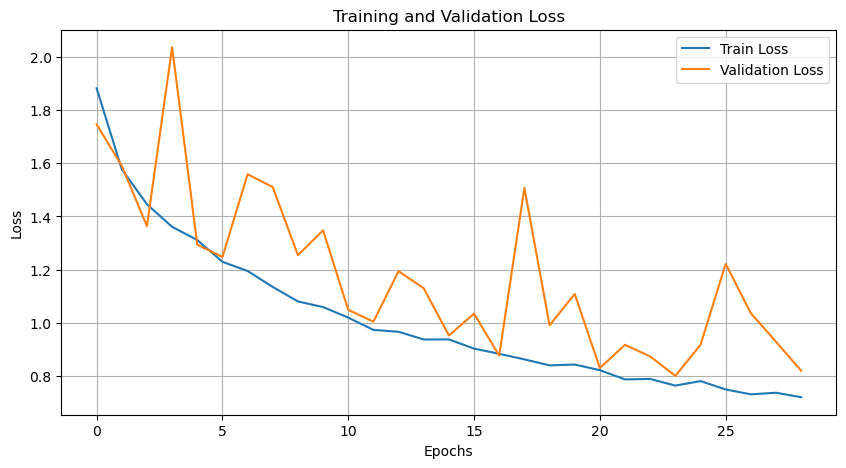

Accuracy: 0.7473

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.75      0.89      0.81       387
           1       0.77      0.85      0.81       395
           2       0.65      0.86      0.74       357
           3       0.62      0.59      0.61       386
           4       0.86      0.69      0.77       409
           5       0.87      0.65      0.75       394
           6       0.80      0.82      0.81       389
           7       0.62      0.71      0.66       419
           8       0.76      0.70      0.73       399
           9       0.91      0.71      0.80       390

    accuracy                           0.75      3925
   macro avg       0.76      0.75      0.75      3925
weighted avg       0.76      0.75      0.75      3925



Modelo VGG_bn-3 con configuración: [32, 32, 'M', 64, 64, 'M', 128, 'M', 256, 'M']
Layer (type:depth-idx)                   Output Shape              Param #
VGG_BN                               

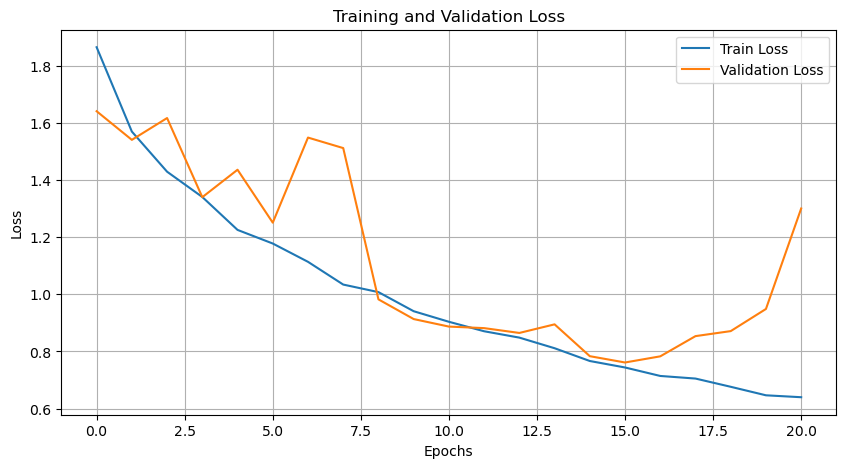

Accuracy: 0.6713

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.75      0.60      0.67       387
           1       0.38      0.97      0.54       395
           2       0.76      0.72      0.74       357
           3       0.69      0.31      0.42       386
           4       0.87      0.76      0.81       409
           5       0.75      0.66      0.71       394
           6       0.82      0.75      0.78       389
           7       0.88      0.50      0.64       419
           8       0.63      0.80      0.71       399
           9       0.91      0.64      0.75       390

    accuracy                           0.67      3925
   macro avg       0.74      0.67      0.68      3925
weighted avg       0.74      0.67      0.68      3925



Modelo VGG_bn-4 con configuración: [32, 32, 'M', 64, 64, 'M', 128, 128, 'M', 256, 256, 'M']
Layer (type:depth-idx)                   Output Shape              Param #
VGG_BN                     

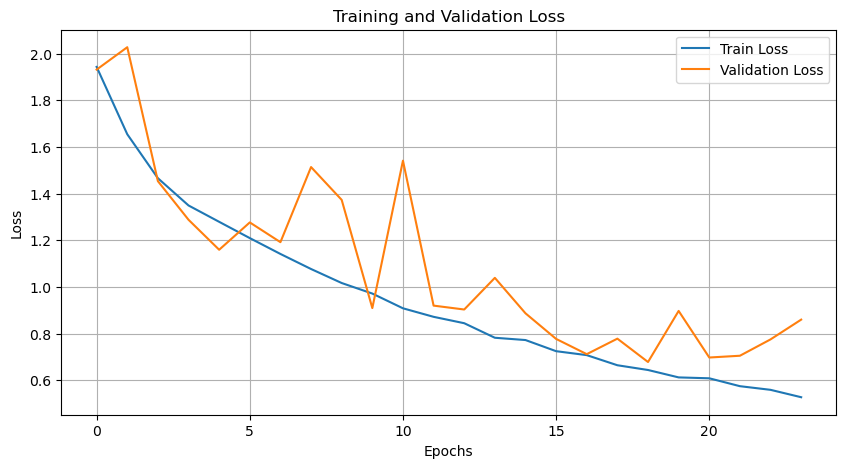

Accuracy: 0.7312

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.67      0.92      0.78       387
           1       0.93      0.81      0.86       395
           2       0.50      0.93      0.65       357
           3       0.65      0.39      0.49       386
           4       0.97      0.75      0.85       409
           5       0.95      0.55      0.69       394
           6       0.60      0.92      0.72       389
           7       0.81      0.48      0.61       419
           8       0.75      0.82      0.78       399
           9       0.89      0.78      0.83       390

    accuracy                           0.73      3925
   macro avg       0.77      0.73      0.73      3925
weighted avg       0.78      0.73      0.73      3925



Modelo VGG_bn-5 con configuración: [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']
Layer (type:depth-idx)                   Output Shape              Param #
VGG_BN    

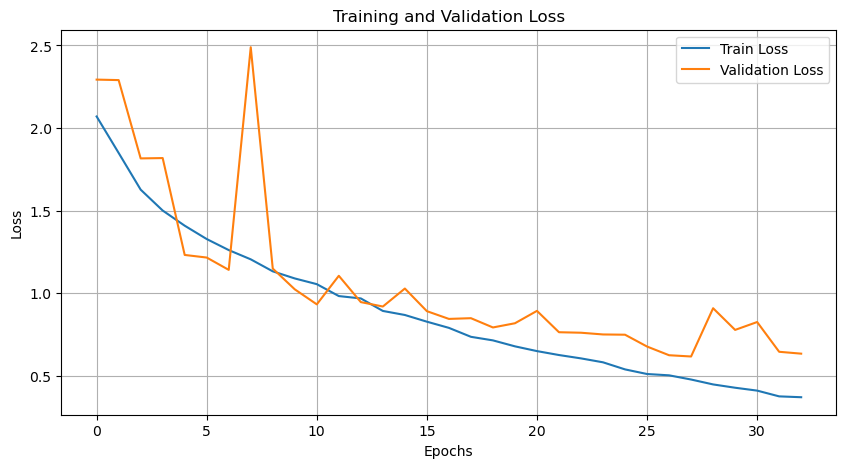

Accuracy: 0.8359

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.91      0.84      0.87       387
           1       0.96      0.87      0.91       395
           2       0.80      0.87      0.83       357
           3       0.74      0.70      0.72       386
           4       0.92      0.89      0.90       409
           5       0.87      0.81      0.84       394
           6       0.91      0.79      0.85       389
           7       0.71      0.84      0.77       419
           8       0.79      0.87      0.83       399
           9       0.83      0.89      0.86       390

    accuracy                           0.84      3925
   macro avg       0.84      0.84      0.84      3925
weighted avg       0.84      0.84      0.84      3925



Modelo VGG_bn-6 con configuración: [64, 64, 64, 64, 'M', 128, 128, 128, 128, 'M', 256, 256, 256, 256, 'M', 512, 512, 512, 512, 'M', 512, 512, 512, 512, 'M']
Layer (type:depth-idx)               

In [ ]:
for i, cfg in enumerate(cfgs):
    print(f"Modelo VGG_bn-{i+1} con configuración: {cfg}")
    model = VGG_BN(cfg, 3, 10).to(DEVICE)
    print(summary(model, input_size=(BATCH_SIZE, 3, DIM, DIM)))
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    train_losses, val_losses = train(
        model=model,
        optimizer=optimizer,
        criterion=CRITERION,
        train_loader=train_loader,
        val_loader=test_loader,
        device=DEVICE,
        do_early_stopping=True,
        patience=5,
        epochs=EPOCHS,
    )
    plot_training(train_losses, val_losses)
    model_classification_report(model, test_loader, device=DEVICE, nclasses=10)
    print("\n" + "=" * 50 + "\n")

In [ ]:
class BasicBlock(nn.Module):
    """
    Bloque básico de ResNet-34 con 2 convoluciones 3x3
    """

    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()

        # Primera convolución
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        # Segunda convolución
        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        # Primera conv + bn + relu
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        # Segunda conv + bn
        out = self.conv2(out)
        out = self.bn2(out)

        # Skip connection
        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class ResNet34(nn.Module):
    """
    ResNet-34: [3, 4, 6, 3] bloques
    """

    def __init__(self, num_classes=1000, in_channels=3):
        super(ResNet34, self).__init__()

        self.in_channels = 64

        # Capa inicial (stem)
        self.conv1 = nn.Conv2d(
            in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # 4 stages de bloques residuales
        self.layer1 = self._make_layer(64, 3, stride=1)  # 3 bloques
        self.layer2 = self._make_layer(128, 4, stride=2)  # 4 bloques
        self.layer3 = self._make_layer(256, 6, stride=2)  # 6 bloques
        self.layer4 = self._make_layer(512, 3, stride=2)  # 3 bloques

        # Clasificador
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

        # Inicialización de pesos
        self._initialize_weights()

    def _make_layer(self, out_channels, blocks, stride):
        """
        Crea una secuencia de bloques residuales
        """
        downsample = None

        # Si cambiamos el tamaño o los canales, necesitamos adaptar el skip connection
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),
            )

        layers = []
        # Primer bloque (puede tener stride=2 para downsample)
        layers.append(BasicBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels

        # Resto de bloques (stride=1)
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    def _initialize_weights(self):
        """
        Inicialización de He (Kaiming) para mejor convergencia
        """
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Stem
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Bloques residuales
        x = self.layer1(x)  # 64 channels
        x = self.layer2(x)  # 128 channels
        x = self.layer3(x)  # 256 channels
        x = self.layer4(x)  # 512 channels

        # Pooling global y clasificador
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

    def extract_features(self, x, layer="layer4"):
        """
        Extrae features de una capa intermedia (útil para transfer learning)
        """
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        feat1 = self.layer1(x)
        if layer == "layer1":
            return feat1

        feat2 = self.layer2(feat1)
        if layer == "layer2":
            return feat2

        feat3 = self.layer3(feat2)
        if layer == "layer3":
            return feat3

        feat4 = self.layer4(feat3)
        return feat4

Modelo ResNet-34
Layer (type:depth-idx)                   Output Shape              Param #
ResNet34                                 [16, 20]                  --
├─Conv2d: 1-1                            [16, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [16, 64, 112, 112]        128
├─ReLU: 1-3                              [16, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [16, 64, 56, 56]          --
├─Sequential: 1-5                        [16, 64, 56, 56]          --
│    └─BasicBlock: 2-1                   [16, 64, 56, 56]          --
│    │    └─Conv2d: 3-1                  [16, 64, 56, 56]          36,864
│    │    └─BatchNorm2d: 3-2             [16, 64, 56, 56]          128
│    │    └─ReLU: 3-3                    [16, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [16, 64, 56, 56]          36,864
│    │    └─BatchNorm2d: 3-5             [16, 64, 56, 56]          128
│    │    └─ReLU: 3-6                    [16, 64, 56, 

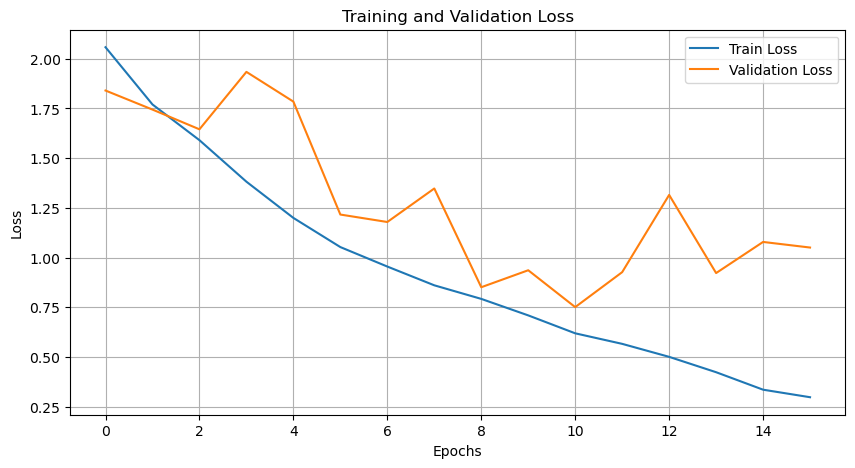

Accuracy: 0.7210

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.77      0.86      0.81       387
           1       0.87      0.72      0.79       395
           2       0.76      0.77      0.76       357
           3       0.64      0.51      0.57       386
           4       0.86      0.74      0.80       409
           5       0.78      0.75      0.76       394
           6       0.85      0.74      0.79       389
           7       0.87      0.54      0.67       419
           8       0.42      0.94      0.59       399
           9       0.88      0.65      0.75       390

    accuracy                           0.72      3925
   macro avg       0.77      0.72      0.73      3925
weighted avg       0.77      0.72      0.73      3925



In [ ]:
print(f"Modelo ResNet-34")
model = ResNet34(num_classes=20, in_channels=3).to(DEVICE)
print(summary(model, input_size=(BATCH_SIZE, 3, DIM, DIM)))
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
train_losses, val_losses = train(
    model=model,
    optimizer=optimizer,
    criterion=CRITERION,
    train_loader=train_loader,
    val_loader=test_loader,
    device=DEVICE,
    do_early_stopping=True,
    patience=5,
    epochs=EPOCHS,
)
plot_training(train_losses, val_losses)
model_classification_report(model, test_loader, device=DEVICE, nclasses=10)